In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings

import arviz_plots as azp
import arviz_stats as azs
import numpy as np
import pandas as pd
from matplotlib import pyplot
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from utility import (
    build_bayesian_model,
    build_mixture_baseline,
    calculate_data_masks,
    calculate_empirical_sigma_stats,
    compute_psis_weights,
    evaluate_mixture_model,
    exctract_pymc_groups_data,
    fit_bayesian_model,
    get_mixture_residuals,
    plot_loo_calibration_curve_with_reference,
    plot_mixture_residuals,
    prepare_bayesian_model_args,
    prepare_hierarchical_noise_args,
    prepare_model_input,
)

warnings.filterwarnings("ignore")

%config InlineBackend.figure_format = 'retina'  # high resolution figures
azp.style.use("arviz-darkgrid")  # type: ignore

In [3]:
RANDOM_SEED = 14

Empirical Standard Deviations by Setpoint:
Setpoint  80 psi: σ_unscaled = 2.700 (n=39)
Setpoint 100 psi: σ_unscaled = 2.824 (n=28)
Setpoint 140 psi: σ_unscaled = 3.045 (n=34)
Setpoint 180 psi: σ_unscaled = 2.952 (n=29)

Overall: weighted mean σ_unscaled = 2.873, range normalized by mean = 12.00% spread around mean = [-6.02%, 5.97%]
Prepare the dataset for regressing outlet-pressure residuals against their respective setpoints.
autocorrelation changed from original 0.9661561858376039 to 0.03004635898746591.

Roughly 0.072 of variance can be explained by features altogether after removing outlet_pressure_sp.


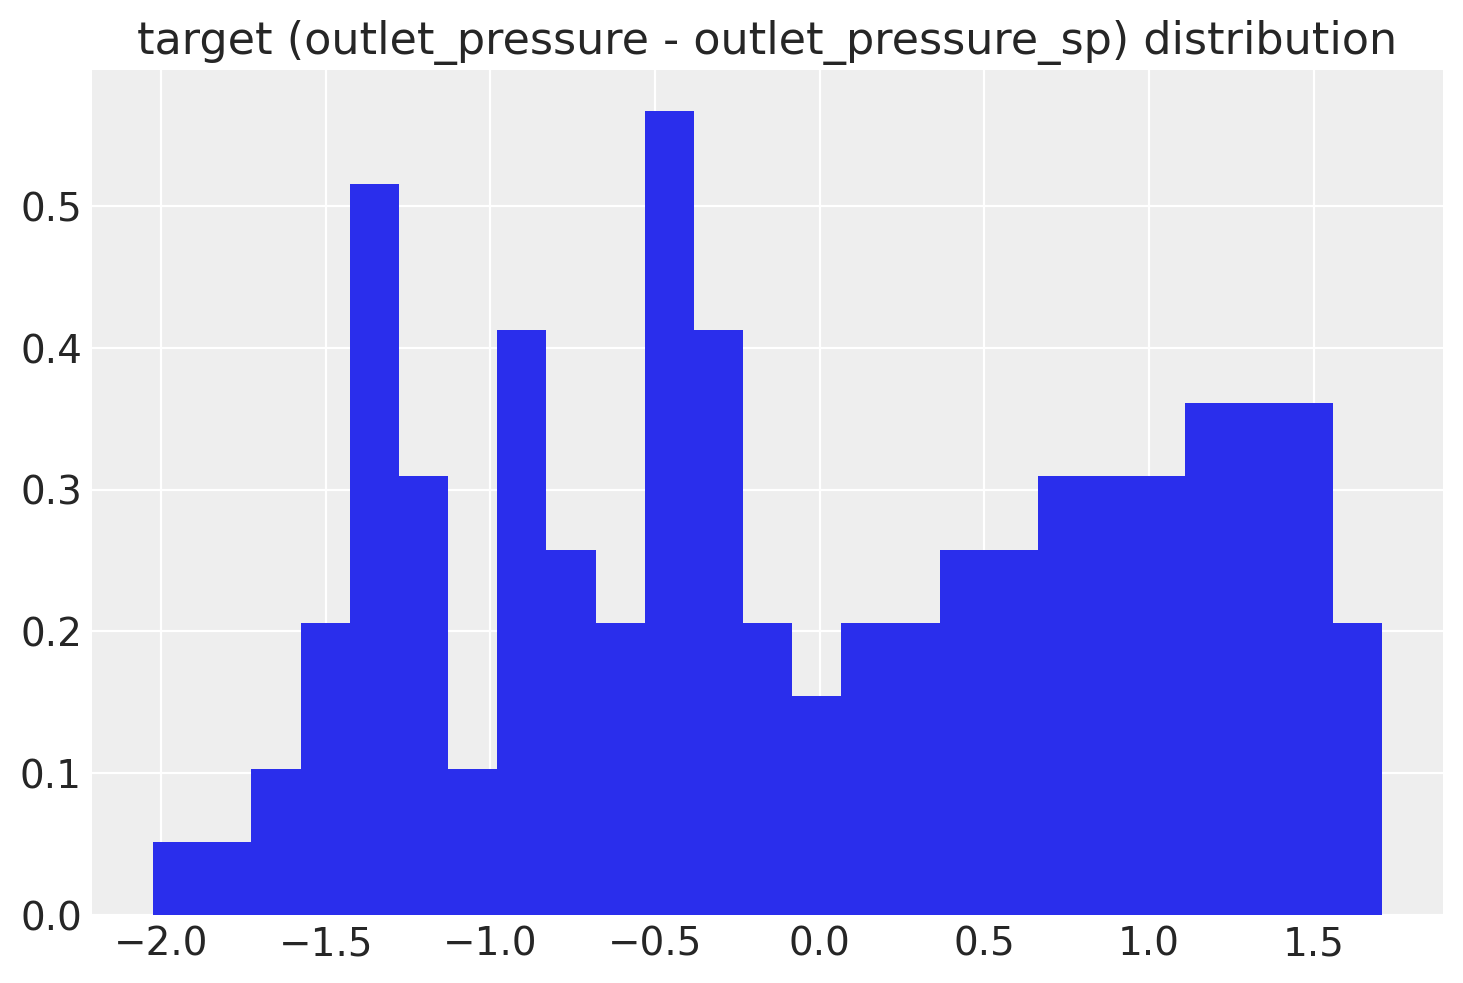

In [4]:
data = pd.read_csv("ds_compressor_data.csv")
data["timestamp"] = pd.to_datetime(data["timestamp"], utc=True)
data = data.set_index("timestamp")
data = data.sort_index()
data, X, y = prepare_model_input(data, None, feature_engineering_allowed=True)
baseline_mask, shutin_mask = calculate_data_masks(
    data, rolling_mean_std_multiplier=1.25
)
X_baseline = X.loc[baseline_mask]
y_baseline = y.loc[baseline_mask]

setpoint_unique, setpoint_index, map_sp_to_idx = prepare_hierarchical_noise_args(
    X_baseline
)
empirical_stats, mean_std, range_to_mean_ratio, min_std, max_std = calculate_empirical_sigma_stats(
    X_baseline, y_baseline, setpoint_unique.tolist()
)

print(
    "Prepare the dataset for regressing outlet-pressure residuals against their"
    " respective setpoints."
)
data_residual = prepare_bayesian_model_args(
    X_baseline, y_baseline, shuffle_baseline=False, residual_target=True
)
lr = LinearRegression()
lr.fit(data_residual.X_scaled, data_residual.y_scaled)
y_pred = lr.predict(data_residual.X_scaled)
r2 = r2_score(data_residual.y_scaled, y_pred)
print(
    f"\nRoughly {r2:.3f} of variance can be explained by features altogether after"
    " removing outlet_pressure_sp."
)
pyplot.hist(data_residual.y_scaled, density=True, bins=25)
pyplot.title("target (outlet_pressure - outlet_pressure_sp) distribution")
pyplot.show()

In [5]:
noise_kwargs = {
    "sigma_mu_mu": mean_std / data_residual.y_std,
    "sigma_mu_sd": np.log(1 + 2.5 * range_to_mean_ratio),  # ~30% variation around
    # mean according to np.exp(sigma_mu_sd)
}
coef_kwargs = {"mu": 0.0, "sd": 0.5}

m_residual = build_bayesian_model(
    X=data_residual.X_scaled,
    y=data_residual.y_scaled,
    intercept_sd=0.5,  # fairly strong shrinkag
    coef_kwargs=coef_kwargs,
    noise_kwargs=noise_kwargs,
    random_seed=RANDOM_SEED
)
idata_residual = fit_bayesian_model(m_residual, random_seed=RANDOM_SEED)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.23,31
,3000,0,0.23,15
,3000,0,0.21,31
,3000,0,0.24,63


Sampling: [beta, intercept, log_sigma, y_like]
Sampling: [y_like]


Output()

Output()

Computed from 8000 posterior samples and 130 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -187.54     5.20
p_loo        7.00        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      130  100.0%
   (0.70, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    0    0.0%

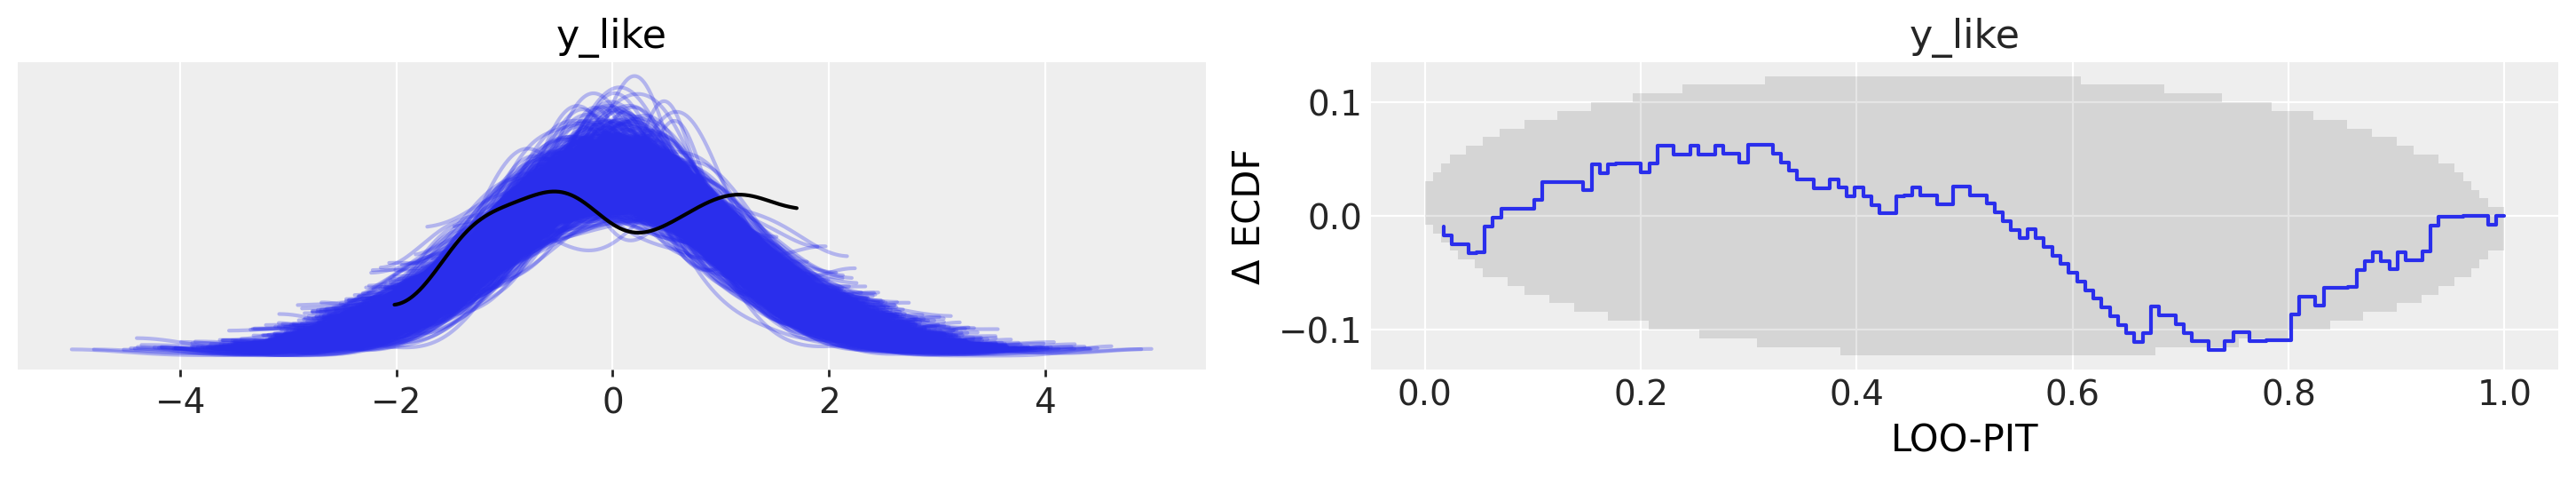

In [6]:
pc = azp.combine_plots(
    idata_residual,
    plots=[
        (azp.plot_ppc_dist, {"num_samples": 1000}),
        (azp.plot_loo_pit, {"envelope_prob": 0.95}),
    ],
    group="posterior_predictive",
)
azs.loo(idata_residual)

In [7]:
### Mixture Model
kwargs = {
    "mu_mu": data_residual.y_scaled.mean(),
    "mu_sigma": 1.0 * data_residual.y_scaled.std(),
    "sigma_sigma": 0.3,
}
# Build and fit
model_mixture = build_mixture_baseline(
    y_deviation=data_residual.y_scaled.to_numpy(),
    kwargs=kwargs,
    n_components=2,
    random_seed=RANDOM_SEED,
)

idata_mixture = fit_bayesian_model(model_mixture, random_seed=RANDOM_SEED)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.58,7
,3000,0,0.53,7
,3000,0,0.55,15
,3000,0,0.55,3


Sampling: [mu_unordered, sigma, weights, y_like]
Sampling: [y_like]


Output()

Output()

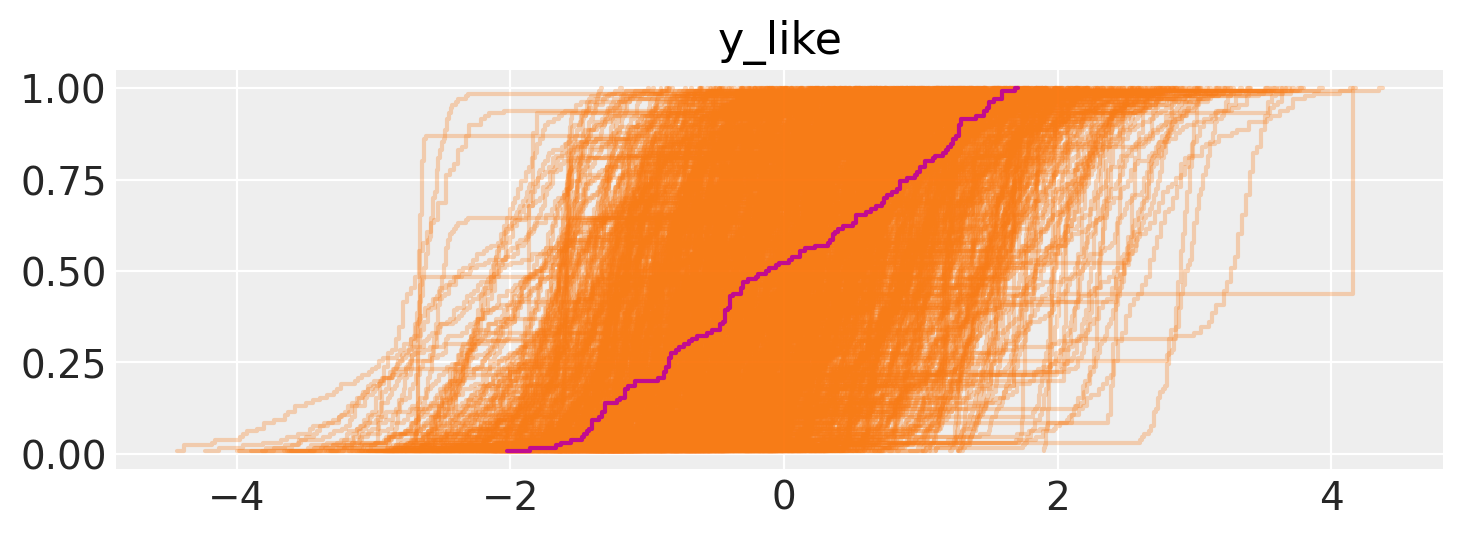

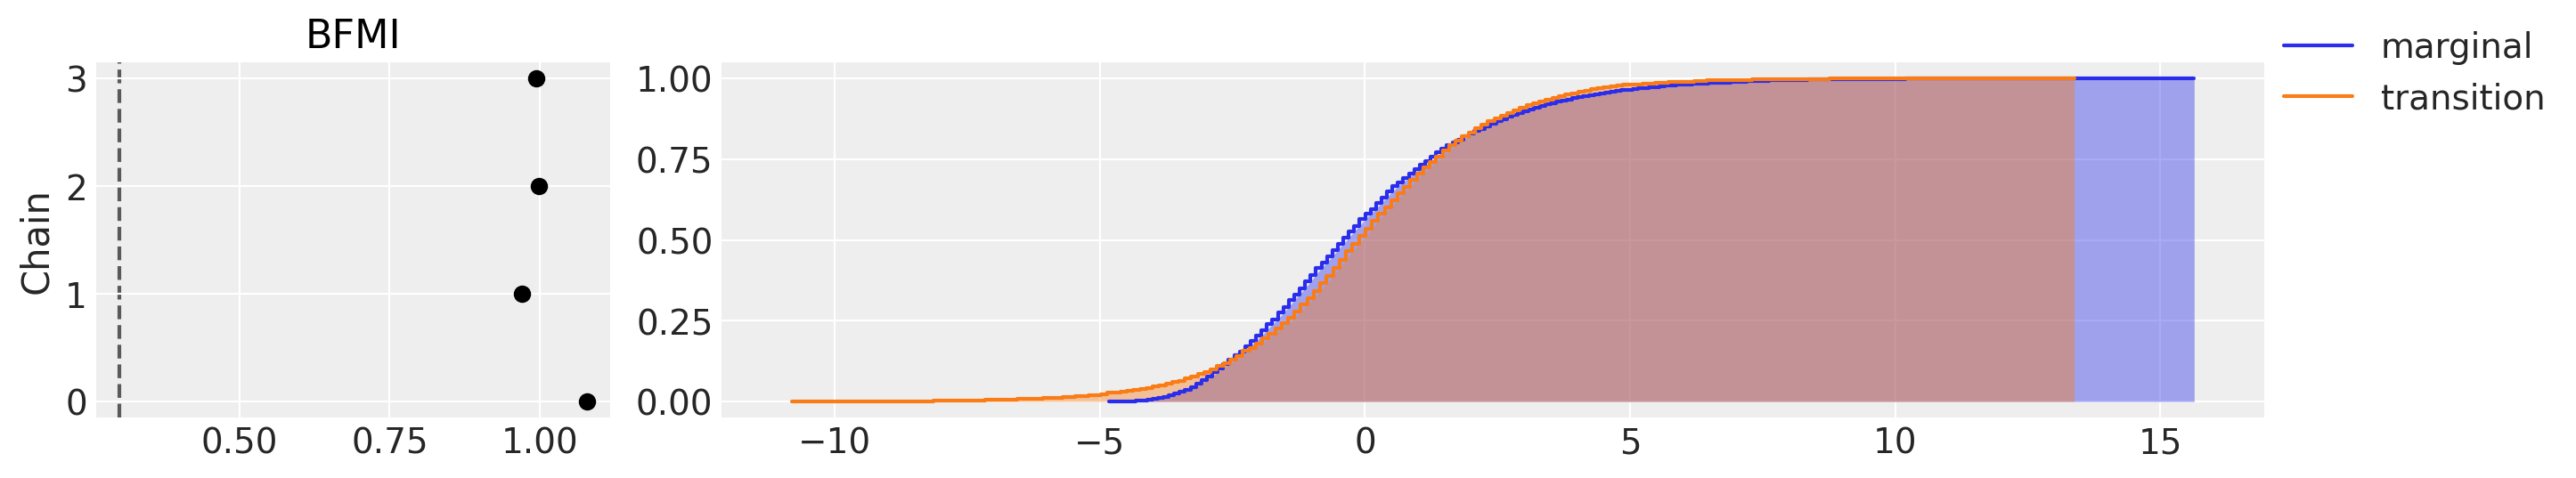

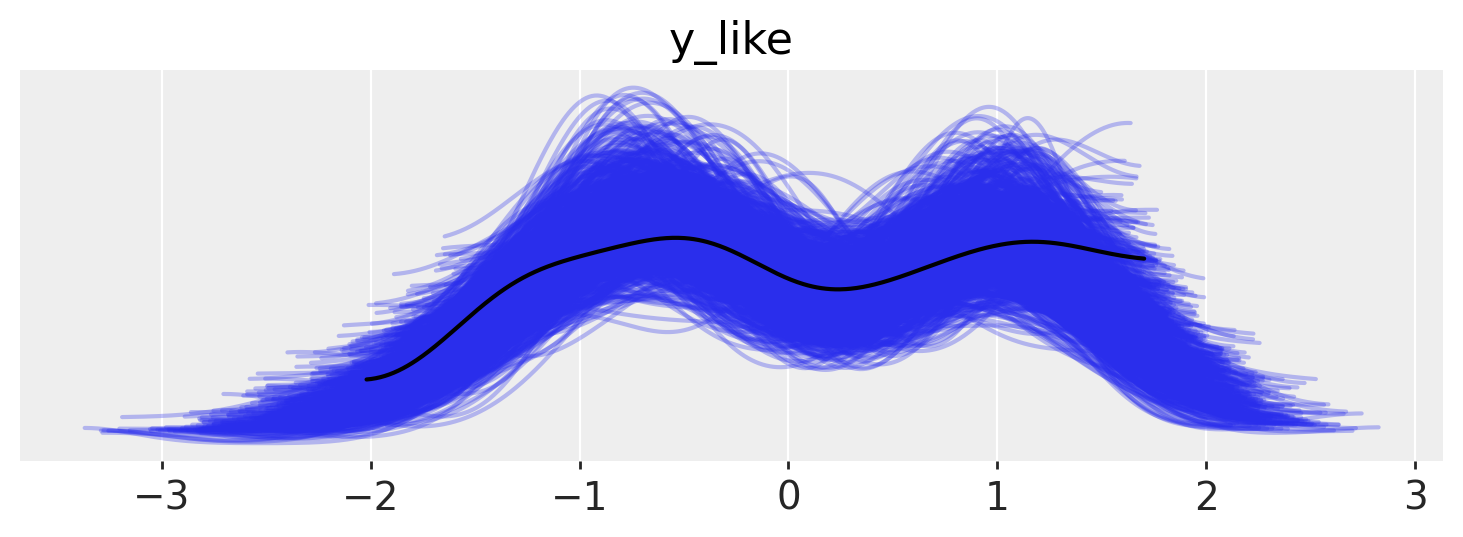

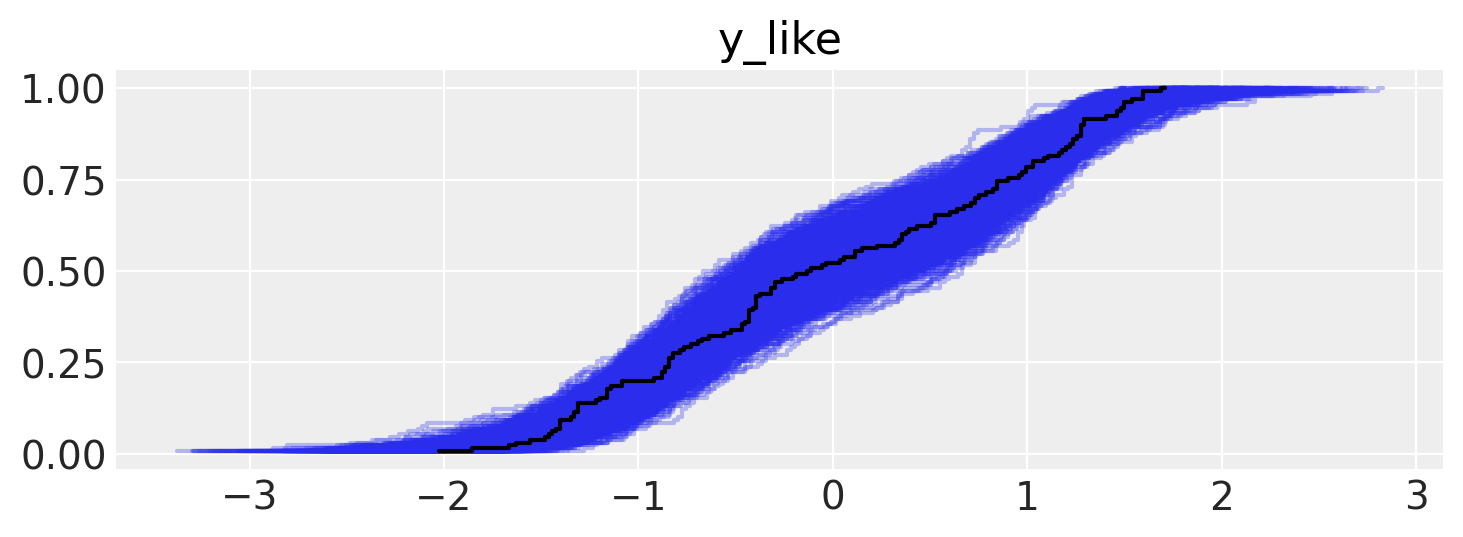

In [8]:
pc = azp.plot_ppc_dist(
    idata_mixture,
    group="prior_predictive",
    kind="ecdf",
    visuals={"predictive_dist": {"color": "C1"}, "observed_dist": {"color": "C3"}},
    num_samples=1000,
)
pc = azp.plot_energy(idata_mixture, kind="ecdf")
pc = azp.plot_ppc_dist(idata_mixture, num_samples=1000)
pc = azp.plot_ppc_dist(idata_mixture, kind="ecdf", num_samples=1000)

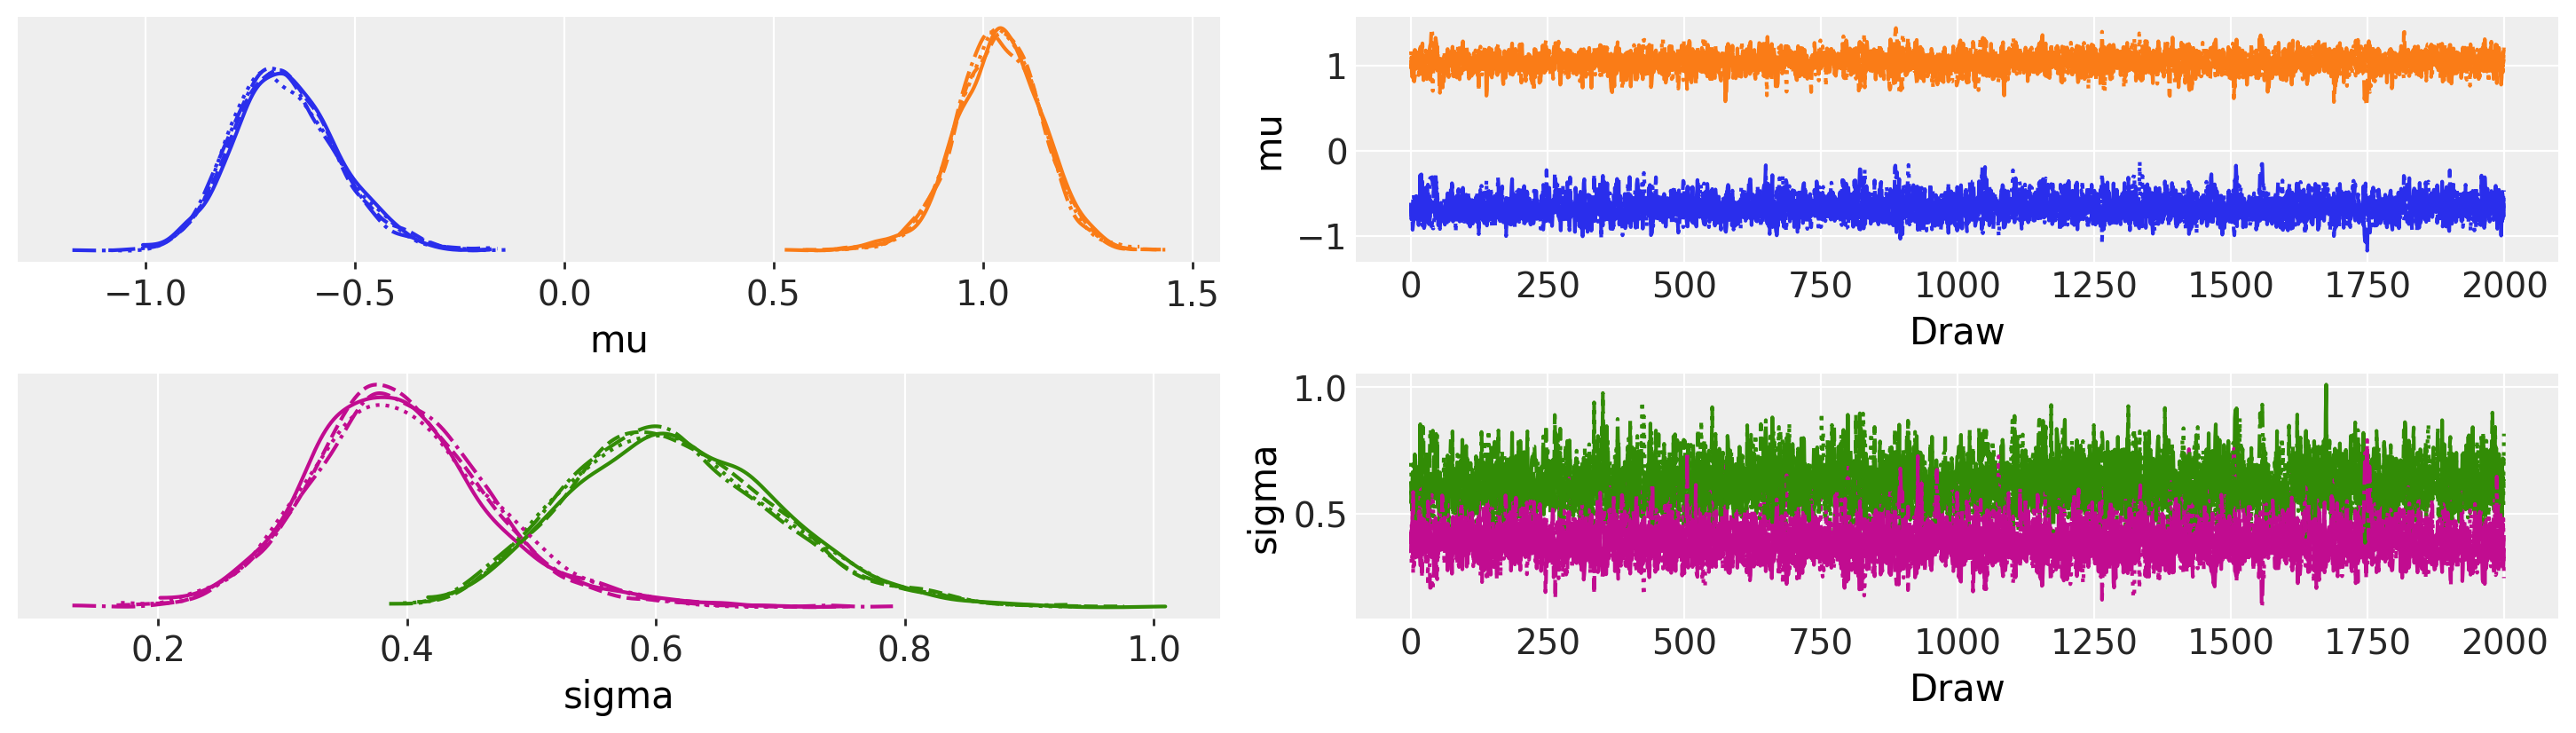

In [9]:
# The sigma overlap is a mild uncertainty about the relative spread of the two
# components, not a sign of misfit or identifiability failure
pc = azp.plot_trace_dist(
    idata_mixture, var_names=["mu", "sigma"], compact=True, combined=False
)

Computed from 8000 posterior samples and 130 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -173.59     4.63
p_loo        4.73        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      130  100.0%
   (0.70, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    0    0.0%



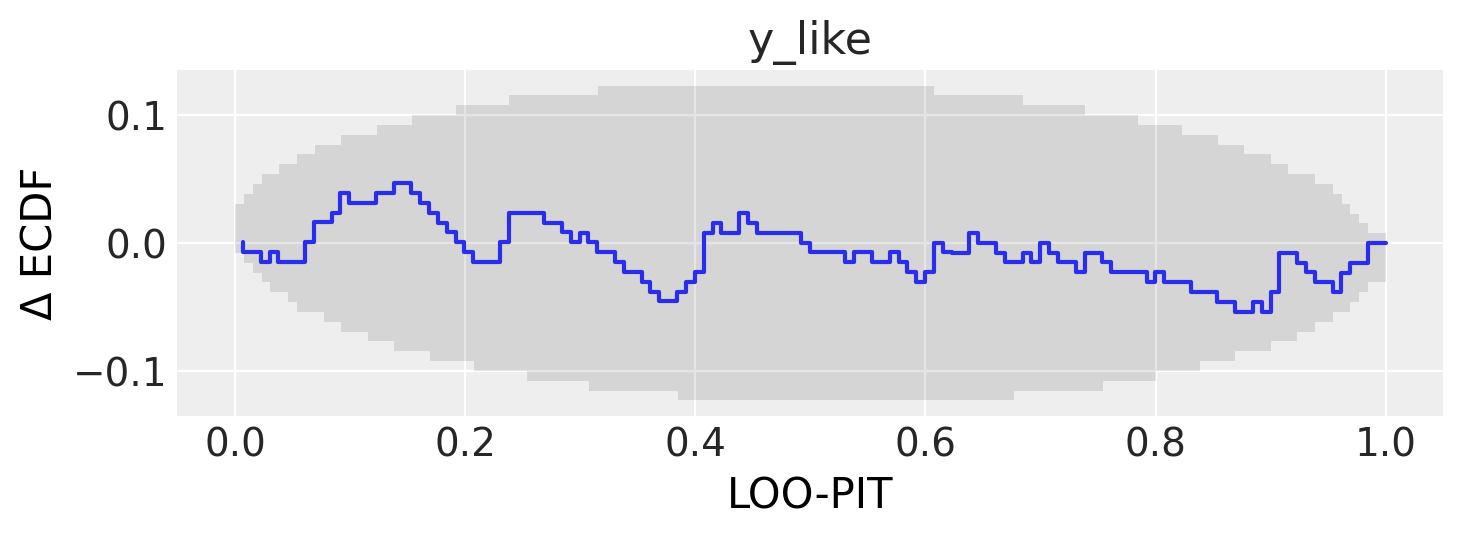

In [10]:
pc = azp.plot_loo_pit(idata_mixture, envelope_prob=0.95)
mixture_model_loo = azs.loo(idata_mixture)
print(mixture_model_loo)

In [11]:
idata_mixture_data = exctract_pymc_groups_data(idata_mixture)
# Compute PSIS weights (these reweight posterior samples to approximate LOO posterior)
weights, pareto_k = compute_psis_weights(-idata_mixture_data.log_likelihood_stacked)


Mean Calibration Error (LOO): 0.015
Weighted Calibration Error (LOO): 0.014
Significantly miscalibrated intervals: 1 out of 20 (5.0%)


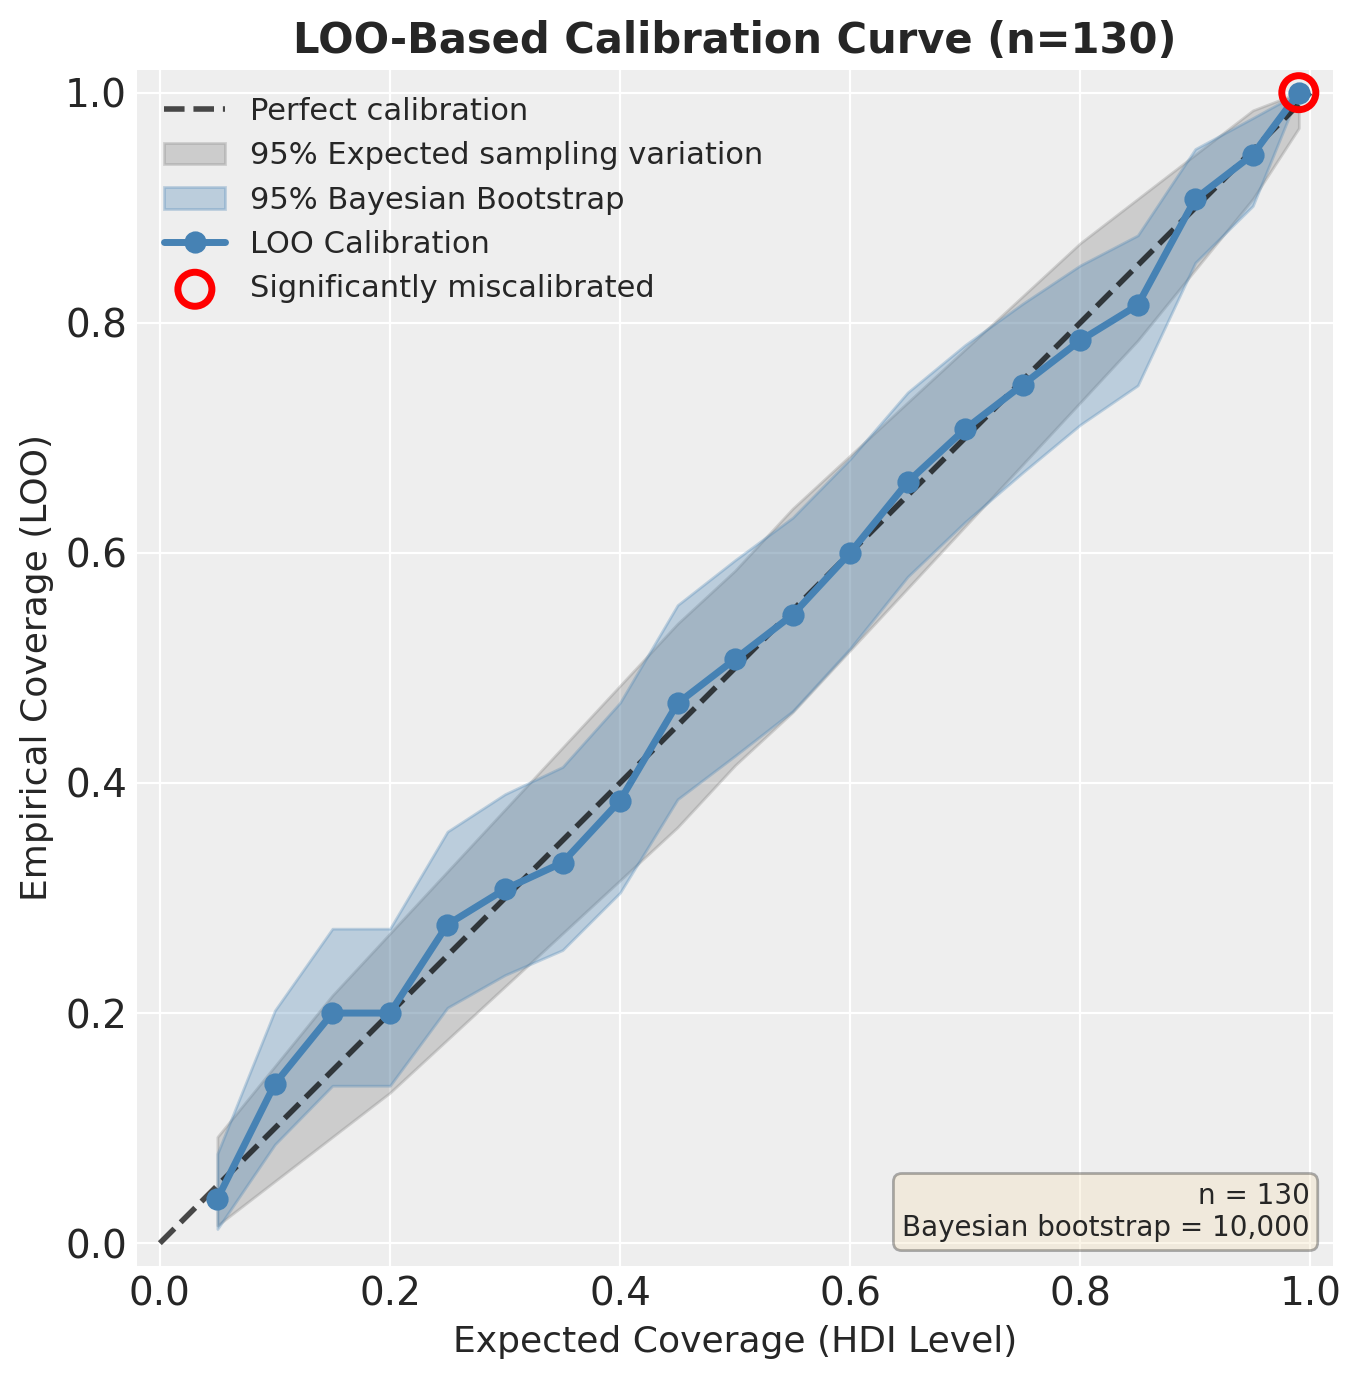

In [12]:
calib_res_mixture_model = plot_loo_calibration_curve_with_reference(
    idata_mixture_data.y_obs,
    idata_mixture_data.y_pred_stacked,
    weights,
    random_seed=RANDOM_SEED,
)

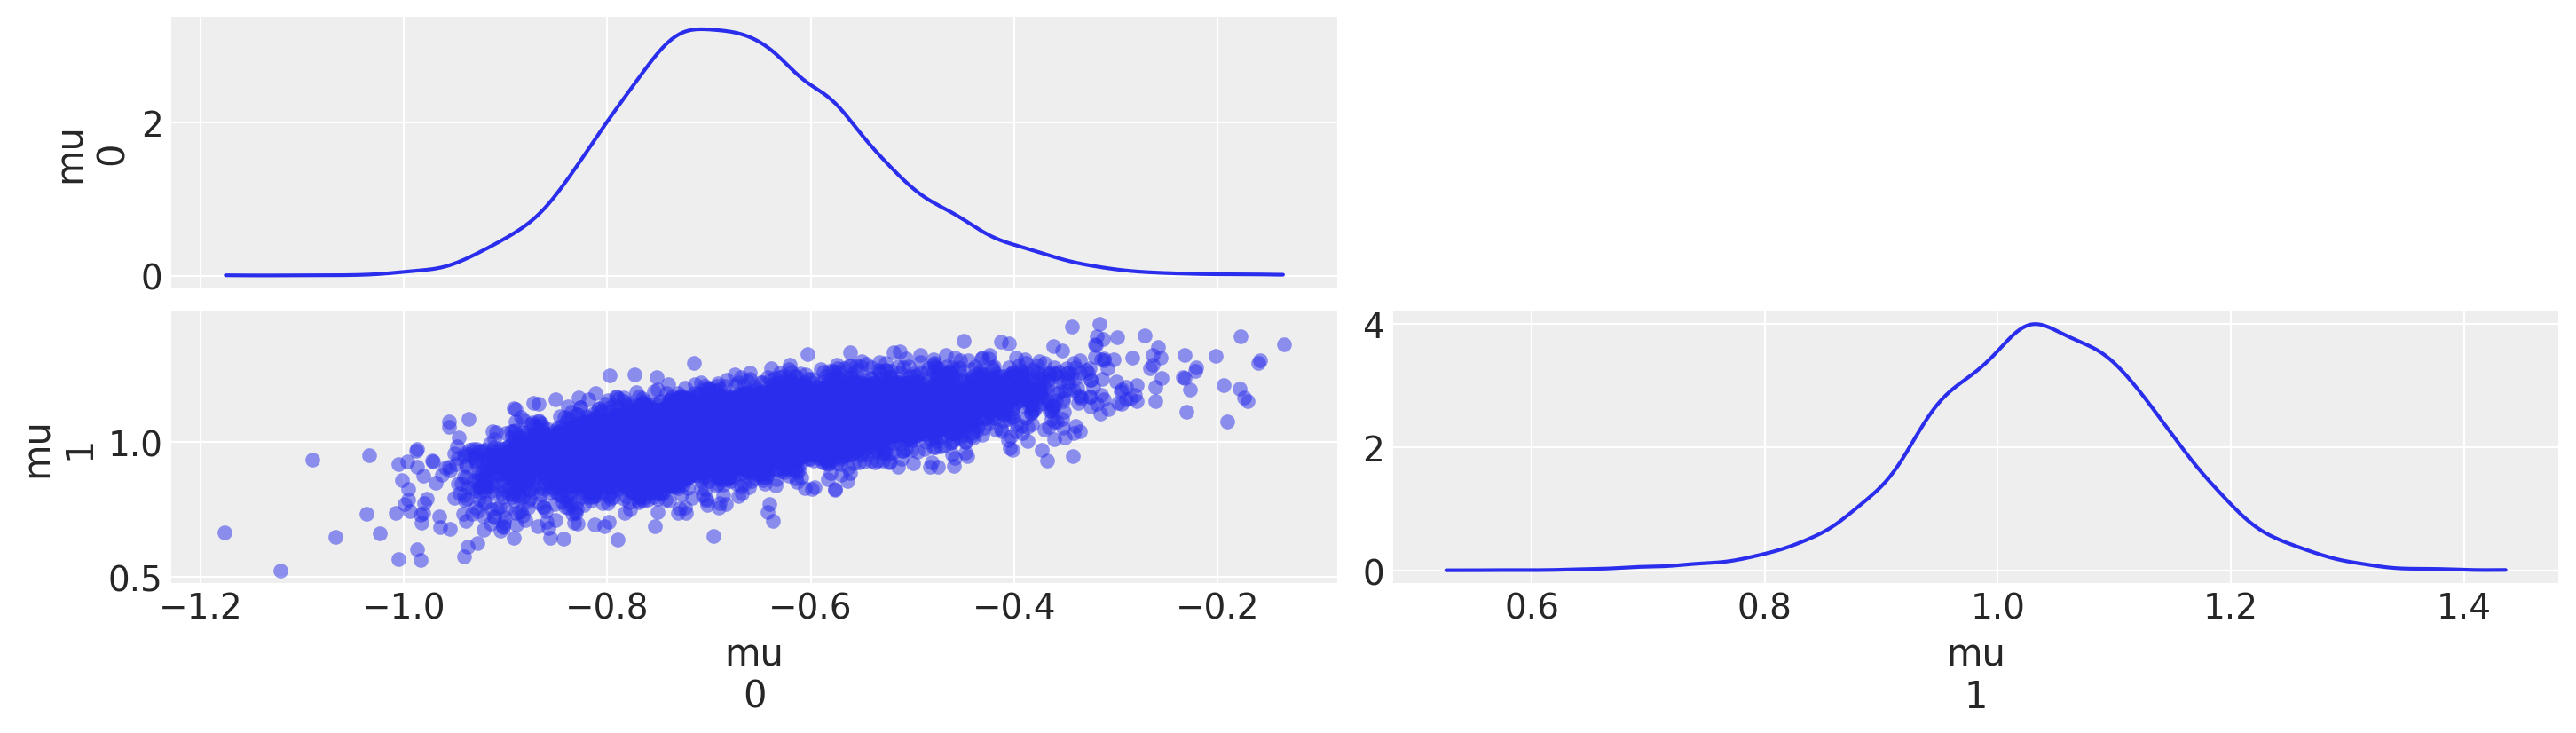

In [13]:
# two well-separated, stable components with no label switching (no mean overlap)
# and a sensible correlation structure (the data has a fixed overall mean, so if
# one component's mean drifts up, the other tends to follow to compensate.).
pc = azp.plot_pair(
    idata_mixture,
    var_names=["mu"],
    visuals={"divergence": True},
    marginal=True,
    marginal_kind="kde",
)

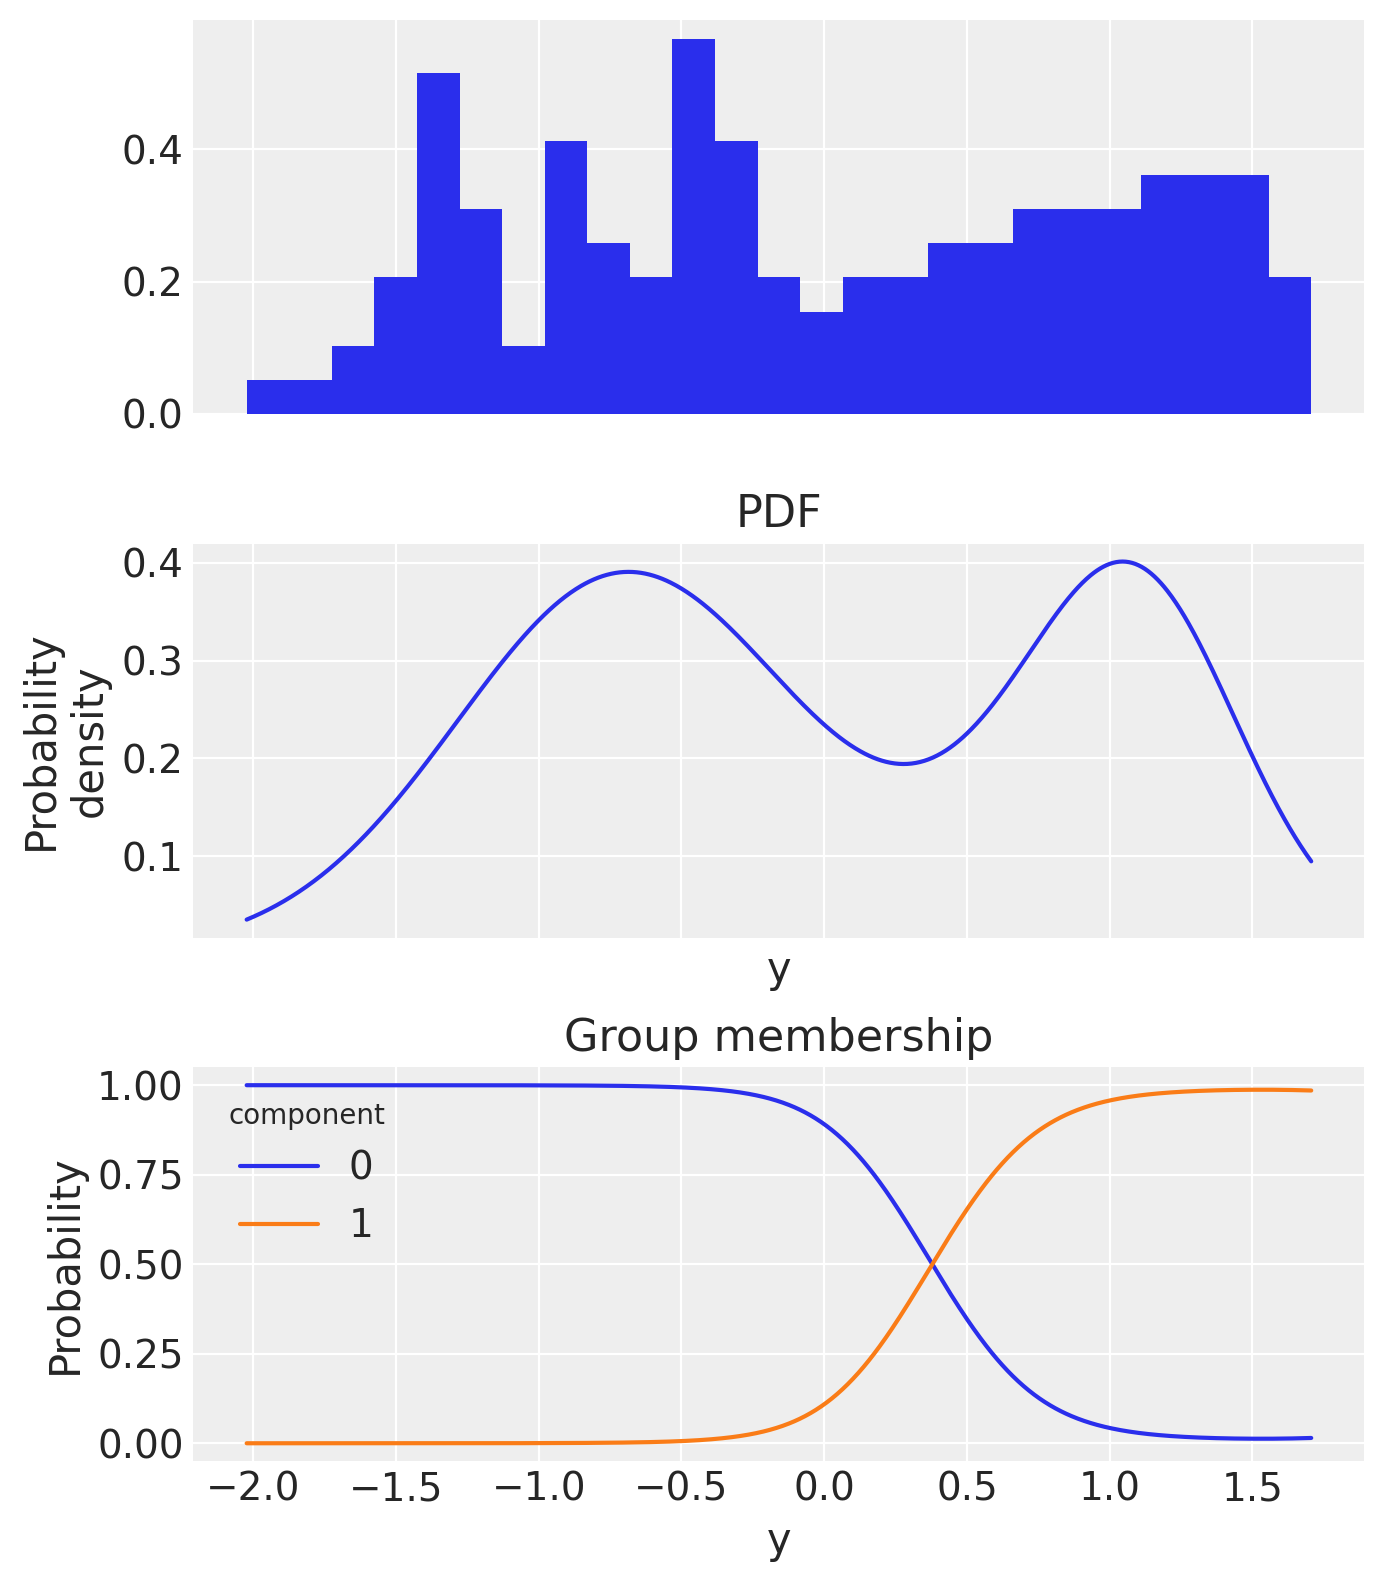

In [14]:
fig = evaluate_mixture_model(
    idata_mixture,
    data_residual.y_scaled,
    y_grid=np.linspace(
        data_residual.y_scaled.min(), data_residual.y_scaled.max(), 1000
    ),
)

Learned mixture parameters:
  weights: [0.60754146 0.39245854]
  mu:      [-0.66563674  1.03805136]
  sigma:   [0.61481909 0.39461776]


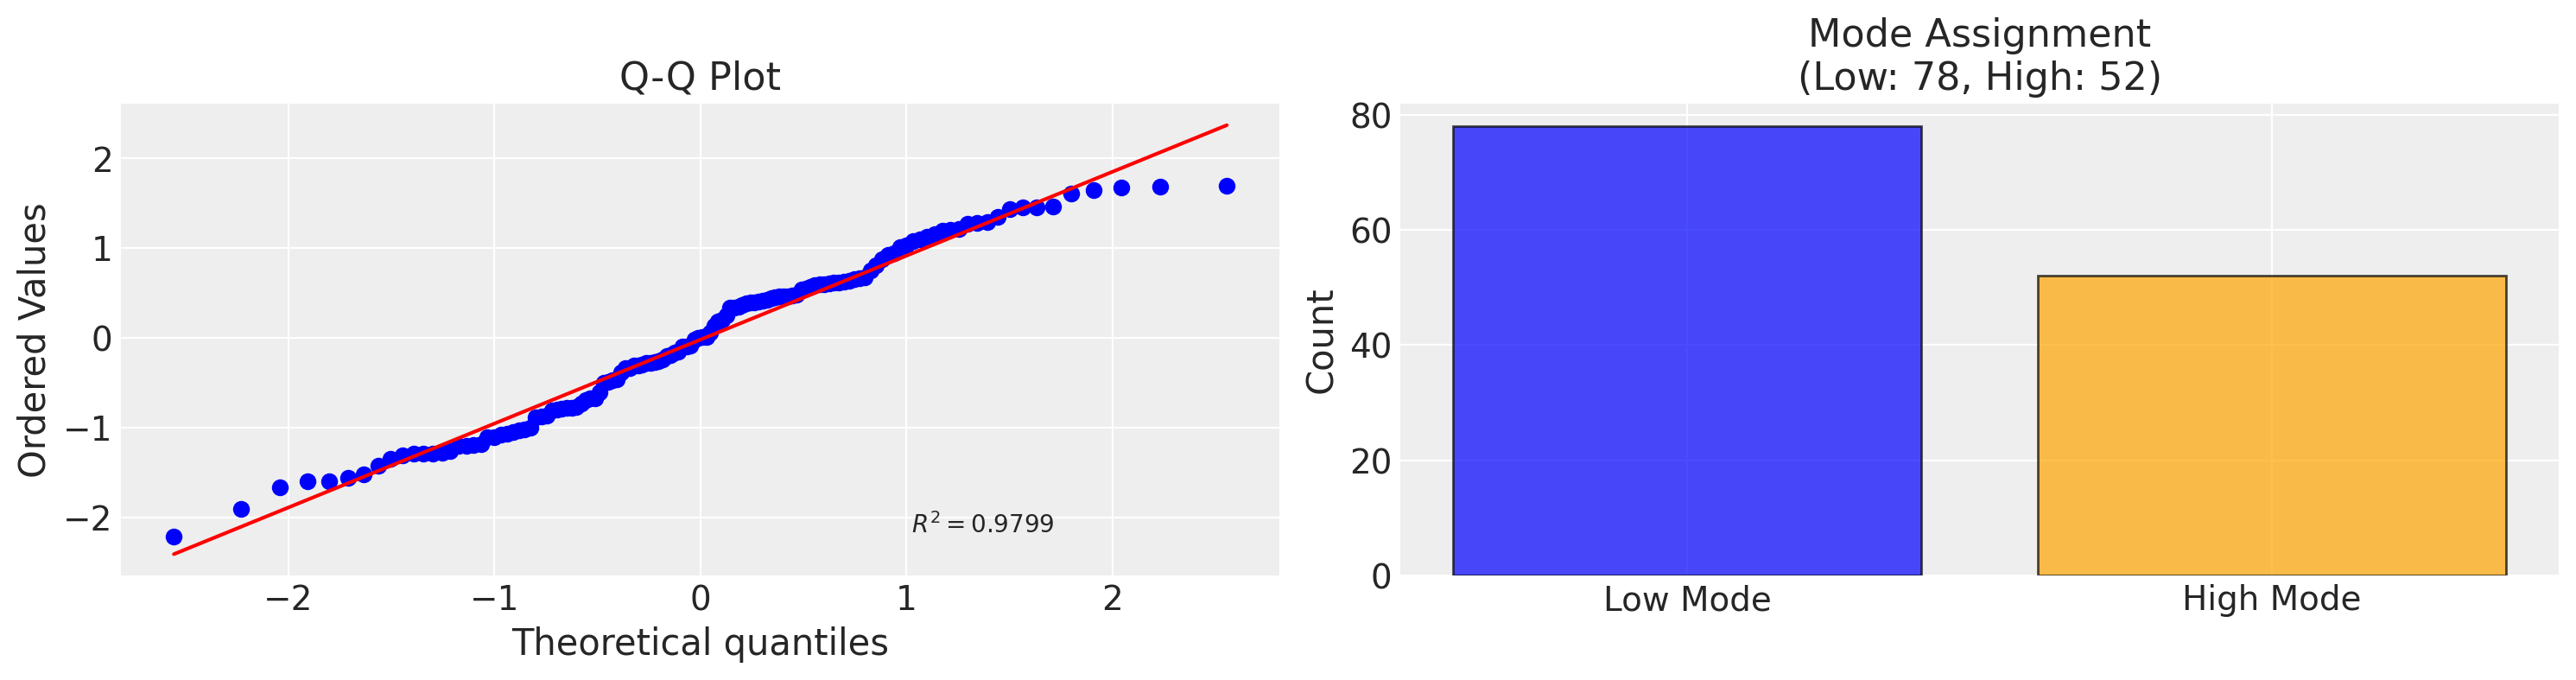

In [15]:
# Get residuals from your fitted mixture model
mixture_model_results = get_mixture_residuals(
    idata_mixture, data_residual.y_scaled.to_numpy()
)
fig_mixture_residuals = plot_mixture_residuals(mixture_model_results)

In [16]:
# Your standardization parameters
y_mean = data_residual.y_mean  # e.g., 5.018
y_std = data_residual.y_std    # e.g., 2.874

# Convert mu to original scale (deviation from setpoint)
mu_original = [
    -0.666 * y_std + y_mean,  # Low mode
    1.038 * y_std + y_mean,   # High mode
]

print(f"Low Mode:  P ≈ SP + {mu_original[0]:.1f} units")
print(f"High Mode: P ≈ SP + {mu_original[1]:.1f} units")

Low Mode:  P ≈ SP + 3.1 units
High Mode: P ≈ SP + 8.0 units


## System Behavior Analysis

| Metric | Low Mode (60.8% of time) | High Mode (39.2% of time) |
|:-------|:-------------------------:|:-------------------------:|
| **Outlet Pressure** | ~3.1 units **ABOVE** setpoint | ~8.0 units **ABOVE** setpoint |
| **Spread (σ)** | 0.615 standardized<br>≈ 1.8 units original | 0.395 standardized<br>≈ 1.1 units original |
| **Control Characteristic** | Tighter control in this mode | Even tighter control (lower σ) |

### Mode Separation
- **Gap between modes:** 1.698 standardized ≈ 4.9 units original
- **Interpretation:** Very distinct separation between operational modes

### Key Insights
- The system operates in two distinct pressure regimes
- Both modes maintain pressure above setpoint, with High Mode showing ~2.6× higher deviation
- Control tightness (variability) is actually better in High Mode despite higher pressure offset
- The 4.9-unit gap between modes confirms clear bimodal behavior